# 🛒 Sales Intelligence & Business Insights Dashboard

## 📌 Project Objective

The goal of this project is to analyze sales data and uncover meaningful business insights.

Using Python and Pandas, this project focuses on:

- Data cleaning
- Sales analysis
- Trend identification
- Regional performance
- Product-level insights
- Business recommendations

---

## 🛠 Tools & Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [3]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show plots inside notebook
%matplotlib inline

In [5]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/sales.csv")

# Display first 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# 🔍 Dataset Understanding

Before performing analysis, it is important to understand:

- Dataset size
- Column names
- Data types
- Missing values
- Overall dataset structure

In [6]:
# ==========================================
# Basic Dataset Information
# ==========================================

# Dataset shape
print("Dataset Shape:")
print(df.shape)

print("\n")

# Column names
print("Columns in Dataset:")
print(df.columns)

print("\n")

# Dataset information
df.info()

Dataset Shape:
(9800, 18)


Columns in Dataset:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   obj

# 🧹 Data Cleaning

Before analysis, the dataset needs to be cleaned and prepared.

This includes:
- Handling missing values
- Fixing column names
- Converting data types
- Checking duplicates

In [7]:
# ==========================================
# Check Missing Values
# ==========================================

df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
# ==========================================
# Remove Missing Values
# ==========================================

df = df.dropna()

# Check missing values again
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

# 🔤 Column Name Cleaning

To improve readability and consistency, column names are cleaned by:

- Converting to lowercase
- Replacing spaces with underscores

In [9]:
# ==========================================
# Clean Column Names
# ==========================================

# Convert column names to lowercase
df.columns = df.columns.str.lower()

# Replace spaces with underscores
df.columns = df.columns.str.replace(" ", "_")

# Display updated column names
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales'],
      dtype='object')

# 📅 Date Conversion

The `order_date` and `ship_date` columns are converted into datetime format.

This allows:
- Time-based analysis
- Monthly trends
- Date calculations

In [10]:
# ==========================================
# Convert Date Columns
# ==========================================

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)

# Convert ship_date to datetime
df["ship_date"] = pd.to_datetime(df["ship_date"], dayfirst=True)

# Check updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9789 non-null   int64         
 1   order_id       9789 non-null   object        
 2   order_date     9789 non-null   datetime64[ns]
 3   ship_date      9789 non-null   datetime64[ns]
 4   ship_mode      9789 non-null   object        
 5   customer_id    9789 non-null   object        
 6   customer_name  9789 non-null   object        
 7   segment        9789 non-null   object        
 8   country        9789 non-null   object        
 9   city           9789 non-null   object        
 10  state          9789 non-null   object        
 11  postal_code    9789 non-null   float64       
 12  region         9789 non-null   object        
 13  product_id     9789 non-null   object        
 14  category       9789 non-null   object        
 15  sub-category   9789 non-nu

# 🔁 Duplicate Checking

Duplicate rows can affect analysis accuracy.

This step checks whether duplicate records exist in the dataset.

In [11]:
# ==========================================
# Check Duplicate Rows
# ==========================================

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


# 🧠 Feature Engineering

New features are created from existing columns to improve analysis.

This includes:
- Order year
- Order month
- Shipping duration

In [12]:
# ==========================================
# Create Time-Based Features
# ==========================================

# Extract year from order date
df["order_year"] = df["order_date"].dt.year

# Extract month name from order date
df["order_month"] = df["order_date"].dt.month_name()

# Calculate shipping duration
df["shipping_days"] = (
    df["ship_date"] - df["order_date"]
).dt.days

# Display first 5 rows
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,order_year,order_month,shipping_days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,November,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,June,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,October,7


# 📊 Sales Analysis

This section focuses on analyzing:

- Total revenue
- Regional performance
- Top-selling products
- Monthly sales trends

In [13]:
# ==========================================
# Total Revenue
# ==========================================

total_revenue = df["sales"].sum()

print("Total Revenue:")
print(round(total_revenue, 2))

Total Revenue:
2252607.41


# 🌍 Regional Sales Analysis

This analysis identifies which regions contribute the highest revenue.

In [14]:
# ==========================================
# Sales by Region
# ==========================================

region_sales = (
    df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64


# 🏆 Top-Selling Products

This analysis identifies products generating the highest sales revenue.

In [15]:
# ==========================================
# Top 10 Products by Sales
# ==========================================

top_products = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64


# 📌 Product Insights

### Key Findings

- Canon imageCLASS 2200 Advanced Copier generated the highest revenue.
- Office equipment products dominate the top-selling list.
- High-value technology products contribute significantly to total sales revenue.

# 📅 Monthly Sales Trend Analysis

This analysis evaluates sales trends across different months to identify seasonal patterns and business performance over time.

In [16]:
# ==========================================
# Monthly Sales Trend
# ==========================================

monthly_sales = (
    df.groupby("order_month")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(monthly_sales)

order_month
November     345041.6110
December     321275.1395
September    300103.4117
October      199496.2947
March        197573.5872
August       157315.9270
May          154086.7237
June         145837.5233
July         145535.6890
April        134988.2506
January       91982.1396
February      59371.1154
Name: sales, dtype: float64


# 📈 Data Visualization

Visualizations help identify patterns, trends, and business insights more effectively.

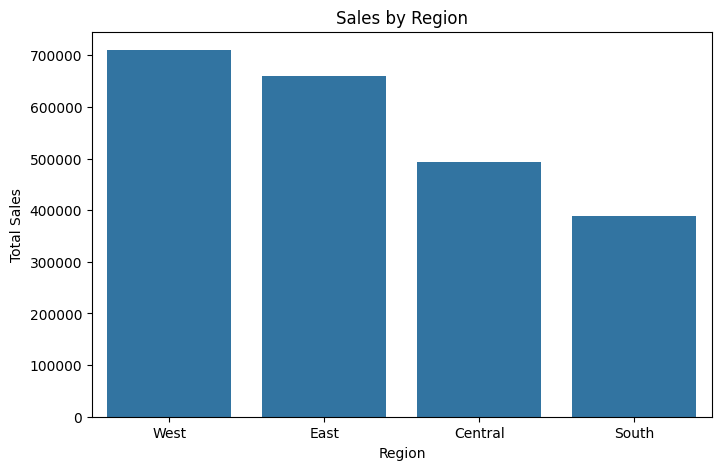

In [17]:
# ==========================================
# Regional Sales Visualization
# ==========================================

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

# 📅 Monthly Sales Trend Visualization

This visualization highlights sales performance trends across different months.

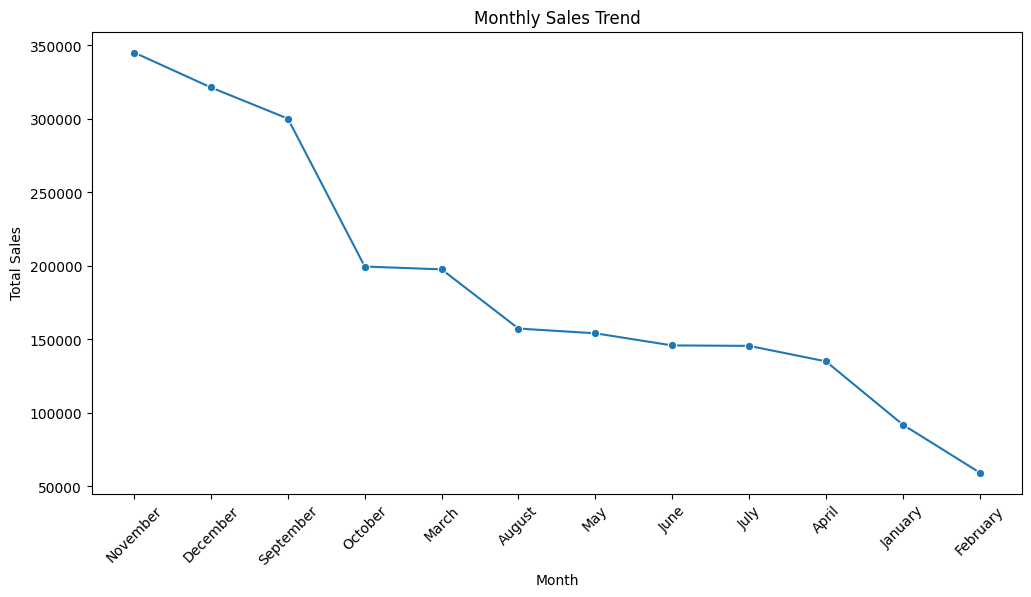

In [18]:
# ==========================================
# Monthly Sales Trend Visualization
# ==========================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

# 🏆 Top-Selling Products Visualization

This visualization highlights the highest revenue-generating products.

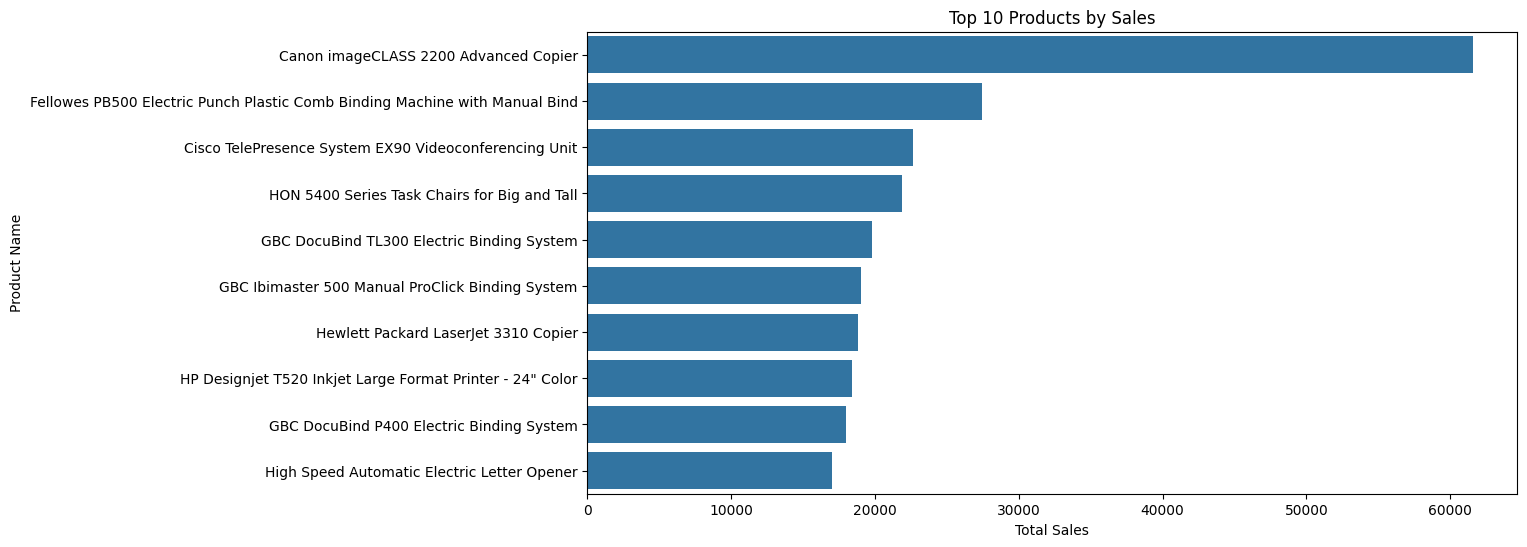

In [19]:
# ==========================================
# Top Products Visualization
# ==========================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.show()

# 📌 Final Business Insights

## Key Findings

### 🌍 Regional Performance
- West region generated the highest sales revenue.
- South region recorded the lowest sales performance.

### 🏆 Product Performance
- Canon imageCLASS 2200 Advanced Copier generated the highest revenue.
- Office equipment products dominate top-selling products.

### 📅 Sales Trends
- November and December showed the highest sales activity.
- February recorded the lowest sales performance.

---

# 💡 Business Recommendations

- Increase inventory before Q4 due to high seasonal demand.
- Focus marketing efforts on high-performing regions.
- Improve promotional campaigns during weaker sales months.
- Invest more in high-performing office technology products.

In [20]:
# ==========================================
# Export Cleaned Dataset
# ==========================================

df.to_csv("../outputs/cleaned_sales_data.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [21]:
print("Thank you !!!")

Thank you !!!
